In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
import pandas as pd

from simulator.supply_chain_engine import (
    SupplyChainEngine
)

In [4]:
df = pd.read_csv("D:/supply_chain_causal_rl/data/raw/sales_train_evaluation.csv")

In [5]:
sales_cols = [
    c
    for c in df.columns
    if c.startswith("d_")
]

item = df.iloc[0]

demand_series = (
    item[sales_cols]
    .values
)

In [6]:
engine = SupplyChainEngine(
    demand_series=demand_series,
    initial_inventory=500
)

In [7]:
order_quantity = 50

In [8]:
results = []

for _ in range(365):

    state = engine.step(
        order_quantity=50
    )

    results.append(state)

    if state["done"]:
        break

In [9]:
df_result = pd.DataFrame(
    results
)

df_result.head(10)

,day,demand,inventory,received,sales,stockout,pipeline,cost,done
0,1,0,500,0,0,0,50,252.0,False
1,2,0,500,0,0,0,100,252.0,False
2,3,0,500,0,0,0,150,252.0,False
3,4,0,500,0,0,0,200,252.0,False
4,5,0,500,0,0,0,250,252.0,False
5,6,0,500,0,0,0,300,252.0,False
6,7,0,500,0,0,0,350,252.0,False
7,8,0,550,50,0,0,350,277.0,False
8,9,0,600,50,0,0,350,302.0,False
9,10,0,650,50,0,0,350,327.0,False


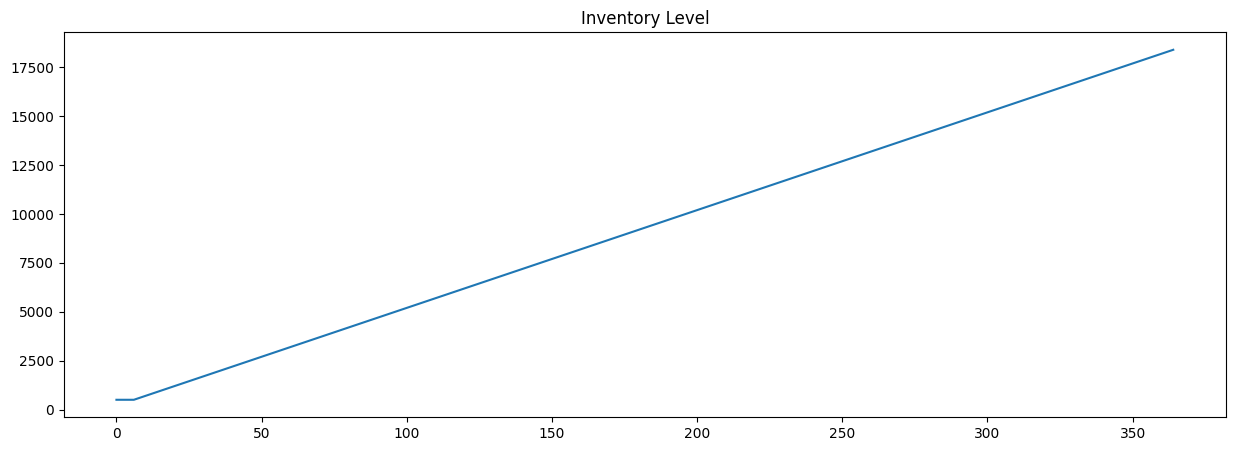

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    df_result["inventory"]
)

plt.title(
    "Inventory Level"
)

plt.show()

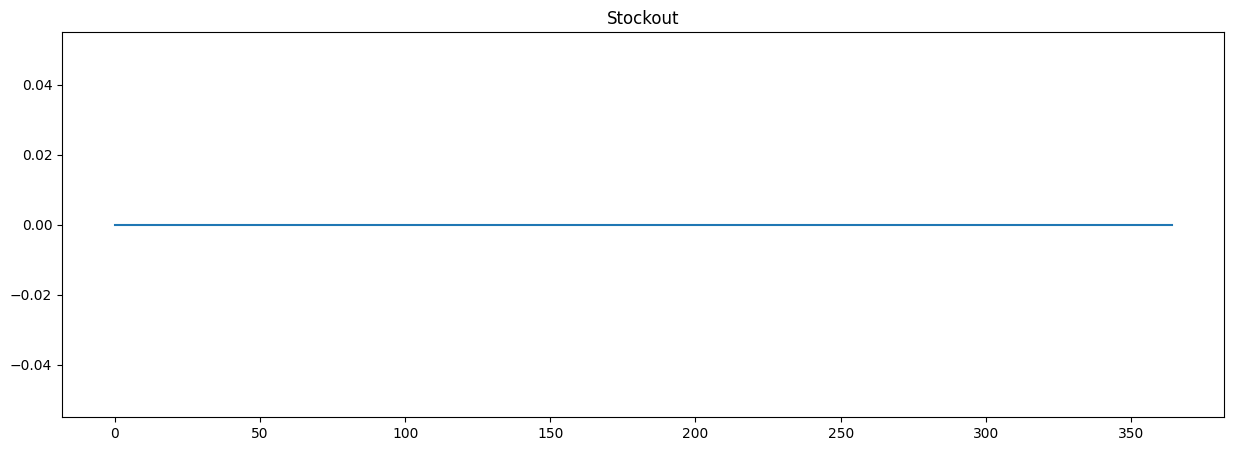

In [11]:
plt.figure(figsize=(15,5))

plt.plot(
    df_result["stockout"]
)

plt.title(
    "Stockout"
)

plt.show()

In [12]:
df_result["cost"].sum()

np.float64(1698505.0)

In [13]:
for order_quantity in [
    20,
    40,
    60,
    80,
    100
]:

    engine = SupplyChainEngine(
        demand_series=demand_series
    )

    total_cost = 0

    for _ in range(365):

        state = engine.step(
            order_quantity
        )

        total_cost += state["cost"]

        if state["done"]:
            break

    print(
        order_quantity,
        total_cost
    )

20 734590.0
40 1377200.0
60 2019810.0
80 2662420.0
100 3305030.0
